<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week5/wine_DL_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 이번 학습의 목표는 다음과 같다.
1. DL(Deep Learning) 프로그래밍 실습
---
 ML과 DL 실습의 차이점:
1. `X.values`를 해서 **X를 numpy로 바꾼다.**
2. **y(label)** 에 **One-Hot Encoding**을 적용한다.
  > 1. 딥러닝에서는 **y(레이블)을 One-Hot Encoding** 먼저 한다.
  > 2. One-Hot Encoding을 하는 이유는 **Label 간의 순차적인 관계나 크기, 대소 관계를 끊기 위해서**이다.
3. 입력층?, 출력층?이 뭔지
4. 조합?

In [13]:
import pandas as pd
import numpy as np

In [14]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week3/wine.csv'

df = pd.read_csv(path)

df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [15]:
y=df['Wine']
print(y.value_counts())

Wine
2    71
1    59
3    48
Name: count, dtype: int64


In [16]:
X = df.drop('Wine', axis=1)
X.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [17]:
#결측치 확인
X.isnull().sum()

,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0
Color.int,0


# Outlier 확인
**Outlier**란 **이상치**라는 뜻으로, **"전체 데이터의 분포나 경향에서 크게 벗어나는 극단적인 값"** 을 의미한다.

이러한 이상치는 모델의 학습 과정을 방해할 수 있기 때문에 **문제**가 된다.

> ex) 2학년 5반 키 데이터들을 사용할 때, 2학년 5반 내에 키가 3미터인 데이터가 있다면, 잘못 측정된 값일 가능성이 매우 높다. 이렇게 이상치의 경우에는 잘못 측정되고, 입력된 값일 가능성이 높아 주로 제거한다.<br>
> 하지만, **이상치일지라도 무조건 제거하지는 않는다.** 도메인 상식(현실적으로 가능한 값)에 벗어나지 않는 실제 정확히 측정된 값일 수도 있기 때문이다. 이럴 때는 **모델의 목적**에 맞게 제거 또는 수정 또는 그대로 사용한다.

---
# 밑에 코드 실습

밑에 코드는 이상치를 찾는 대표적인 방법인 **IQR(Interquartile Range, 사분위수 범위) 규칙**을 이용한 것으로, 데이터를 **4등분**했을 때, **정상적인 데이터들이 모여있는 범위를 벗어나는 값들**을 **이상치**로 판단한다.

이미지를 통해 보면 다음과 같다.
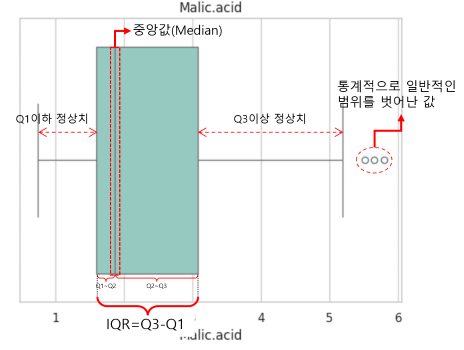

근데, **outlier = 무조건 오류 데이터**는 아니다. outlier는 그저 **다른 데이터에 비해 많이 벗어난 값**이지, 잘못 입력된 값(가능성이 높을 뿐!), 반드시 제거해야 할 값은 아니다.

이 Wine 예시에서도 **잘못 측정 및 입력된 값이 아니기 때문에 제거하지 않는다.**

/tmp/ipykernel_3132/1036733565.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Malic.acid", data=df, palette="Set3")


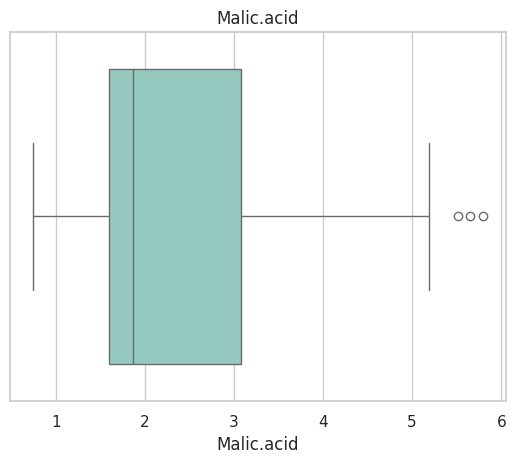

In [18]:
# 특정 칼럼의 범위 확인 및 outlier 확인
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.boxplot(x="Malic.acid", data=df, palette="Set3")
plt.title("Malic.acid")
plt.show()

### ↑ 까지는 **ML**이랑 **똑같다.**
---

---


### ↓ 부터 **DL** 부분!

## 1. 데이터 형태 변환 + One-Hot Encoding + 데이터 분할 + Scaling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X.values
Y = pd.get_dummies(y).values

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(142, 13) (36, 13)
(142, 3) (36, 3)


# 위 코드 해설
### `X = X.values`
- `X`는 원래 pandas의 `DataFrame` 형식임.
- `X.values`를 사용하면 `X`를 NumPy 배열(`ndarray`)로 변환할 수 있다.
- **정리: `X.values`를 통해 `X`의 타입을 `df`→NumPy 배열(`ndarray`)**

#### 왜 NumPy 형식으로 바꾸는가?
- TensorFlow/Keras 같은 딥러닝 라이브러리는 NumPy 배열 형태의 데이터를 매우 잘 처리한다.
- pandas `DataFrame` 상태로도 동작하는 경우가 있지만, NumPy 배열로 바꾸면:
  - 데이터 형식이 더 명확해지고
  - 모델 입력 형태를 다루기 쉬워지며
  - 연산과 shape 확인이 더 일관적이다.

즉, **모델 학습에 더 직접적으로 사용하기 쉬운 형태로 변환하는 것**이다.

---

### `Y = pd.get_dummies(y).values`

- `y`는 정답 레이블이다.
- `pd.get_dummies(y)`는 정답 레이블을 **원-핫 인코딩(One-Hot Encoding)** 해준다.

- 예를 들어 클래스가 3개라면:

  - 클래스 0 → `[1, 0, 0]`
  - 클래스 1 → `[0, 1, 0]`
  - 클래스 2 → `[0, 0, 1]`

#### 왜 원-핫 인코딩을 하는가?
- 클래스 번호를 단순히 `0, 1, 2`로 두면, 모델이 이를 **숫자의 크기 관계(순차 관계 또는 대소 관계)** 로 오해할 수 있다.
- 하지만 와인 클래스는 **대소 관계가 있는 숫자**가 아니라 **서로 다른 범주**이다.
- 따라서 각 클래스를 독립된 위치에 `1`을 두는 방식으로 표현하여, **가짜 순서 관계가 생기지 않도록** 한다.

마지막의 `.values`는 **결과를 NumPy 배열**로 바꾸는 코드이다.

---

### `scaler = StandardScaler()`

- `StandardScaler` 객체를 생성하는 코드이다.
- 아직 실제 변환은 하지 않았고, **표준화(Standardization)를 수행할 도구를 준비한 상태**이다.

표준화는 각 특성을 평균 0, 표준편차 1에 가깝게 맞추는 과정이다.

수식으로는 다음과 같다.

$$
z = \frac{x - \mu}{\sigma}
$$

- $x$: 원래 값
- $\mu$: 평균
- $x-μ: 편차

- $\sigma$: 표준편차($=\sqrt{분산}$, $분산=\text{편차들의 제곱 평균}$)

---

### `X_train = scaler.fit_transform(X_train)`
#### 1) `fit`
- 학습 데이터 `X_train`의 각 열에 대해 평균과 표준편차를 계산한다.
- 즉, 학습 데이터의 통계값을 기억한다.

#### 2) `transform`
- 방금 구한 평균과 표준편차를 이용해 `X_train`을 실제로 표준화한다.

즉, 학습 데이터에 대해 **평균 0, 표준편차 1에 가까운 형태로 변환**하는 것이다.

---

### `X_test = scaler.transform(X_test)`

- 테스트 데이터는 `fit`하지 않고 `transform`만 수행한다.
- 즉, **학습 데이터에서 구한 평균과 표준편차를 그대로 사용하여** 테스트 데이터를 변환한다.

---

### 왜 스케일링을 하는가?

입력 데이터의 각 열은 값의 범위가 서로 다를 수 있다.

예를 들어:

- 어떤 열은 값 범위가 `0 ~ 1`
- 어떤 열은 값 범위가 `100 ~ 1000`

이렇게 되면 숫자가 큰 열이 모델 계산에서 더 큰 영향을 줄 수 있다.

#### 문제점
- 숫자가 크다는 이유만으로 특정 특성이 더 중요하게 작용할 수 있다.
- 학습이 불안정해질 수 있다.
- 경사하강법이 비효율적으로 작동할 수 있다.

#### 스케일링의 목적
- 각 특성의 크기 차이를 줄여
- 모델이 특정 열에 숫자 크기 때문에 과하게 끌리지 않도록 하고
- 더 안정적으로 학습하도록 돕기 위함이다.

---

### 왜 전체 데이터에 `fit`하면 안 되는가?

잘못된 예시는 다음과 같다.

```python
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, ...
```

이렇게 하면 전체 데이터의 평균과 표준편차를 먼저 구하게 되는데, 여기에는 테스트 데이터 정보도 포함된다.

즉:

- 테스트 데이터의 통계값이 전처리 기준에 반영됨
- 모델이 테스트 데이터 분포를 미리 일부 알게 됨

이것을 **데이터 누수(Data Leakage)** 라고 한다.

#### 왜 문제가 되는가?
- 테스트 데이터는 원래 **처음 보는 데이터**처럼 다뤄야 한다.
- 그래야 모델의 일반화 성능을 공정하게 평가할 수 있다.
- 그런데 테스트 데이터 정보가 전처리에 섞이면, 성능이 실제보다 좋게 나올 수 있다.

#### 올바른 방식
- `X_train`에만 `fit`
- `X_train`, `X_test`에는 같은 기준으로 `transform`

즉:

- 학습 데이터로 기준을 정하고
- 테스트 데이터는 그 기준에 맞춰서만 변환해야 한다.

---

### `print(X_train.shape, X_test.shape)` / `print(y_train.shape, y_test.shape)`

- 분할된 데이터의 크기를 확인하는 코드이다.

예를 들어:
- `X_train.shape = (142, 13)`이면  
  학습 데이터 142개, 특성 13개라는 뜻이다.
- `y_train.shape = (142, 3)`이면  
  학습 데이터 142개, 클래스 3개(원-핫 인코딩)라는 뜻이다.


## 2. 딥러닝 모델 생성, 학습, 평가

In [20]:
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 입력층 shape는 입력 열 개수(현재 13)
    layers.Dense(64, activation='relu'), # 은닉층(64개)
    layers.Dropout(0.3), # Dropout으로 랜덤하게 뉴런의 30% 을 제외시킴(끔). overfitting을 막기 위함.
    layers.Dense(32, activation='relu'), # 은닉층(32개)
    layers.Dense(y_train.shape[1], activation='softmax') #출력층 (y_train.shape[1]만큼 출력함.(현재 3))
    # multi-class classification이므로 activation이 softmax
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # One-Hot Encoding이므로 loss function이 categorial_crossentropy
    metrics=['accuracy'] # Classification이므로 metrics가 accurancy이다.
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3363 - loss: 1.1259 - val_accuracy: 0.4828 - val_loss: 1.0134
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6018 - loss: 0.9050 - val_accuracy: 0.6897 - val_loss: 0.8535
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7168 - loss: 0.7740 - val_accuracy: 0.7931 - val_loss: 0.7126
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8230 - loss: 0.6746 - val_accuracy: 0.7931 - val_loss: 0.5991
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8761 - loss: 0.5805 - val_accuracy: 0.8966 - val_loss: 0.4914
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9115 - loss: 0.4946 - val_accuracy: 0.9310 - val_loss: 0.4007
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9646 - loss: 0.4014 - val_accuracy: 0.9655 - val_loss: 0.3211
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8938 - loss: 0.3665 - val_accuracy: 0.9655 - val_loss: 0.2602


# 위 코드 해설

### `import tensorflow as tf`

- TensorFlow는 구글이 개발한 머신러닝/딥러닝 라이브러리이다.
- 행렬 연산, 자동 미분, 신경망 구성, 학습 등을 수행할 수 있게 해준다.
- 딥러닝 모델을 만들 때 자주 사용한다.

---

### `layers = tf.keras.layers`

- `tf.keras.layers`에는 신경망의 각 층을 만드는 도구들이 들어 있다.
- 예를 들어:
  - `Input`
  - `Dense`
  - `Dropout`

등을 사용할 수 있다.

즉, `layers`는 **층(layer)을 만들기 위한 기능 모음**이다.

---

### `models = tf.keras.models`

- `tf.keras.models`는 신경망 전체 구조를 만드는 기능이 들어 있는 모듈이다.
- 예를 들어:
  - `Sequential`
  - `Model`

등을 사용할 수 있다.

즉, `models`는 **전체 모델을 만드는 기능 모음**이다.

---

### 입력층, 은닉층, 출력층이란?

신경망은 보통 다음과 같은 구조를 가진다.

#### 1) 입력층(Input Layer)
- 데이터를 처음 받아들이는 층이다.
- 특성(`feature`)의 개수만큼 입력을 받는다.

#### 2) 은닉층(Hidden Layer)
- 입력 데이터를 가공하고 특징을 학습하는 층이다.
- 사람이 직접 규칙을 주는 것이 아니라, 학습을 통해 가중치를 조정하면서 패턴을 찾는다.

#### 3) 출력층(Output Layer)
- 최종 결과를 내는 층이다.
- 분류 문제에서는 각 클래스에 대한 확률 또는 점수를 출력한다.

---

### `model = models.Sequential([...])`

- `Sequential`은 층을 **순서대로 차례차례 쌓는 가장 기본적인 모델**이다.
- 앞 층의 출력이 다음 층의 입력으로 전달된다.

현재 모델은 다음과 같은 구조이다.

1. 입력층
2. 첫 번째 은닉층
3. Dropout
4. 두 번째 은닉층
5. 출력층

---

### `layers.Input(shape=(X_train.shape[1],))`

- 입력층이다.
- `X_train.shape[1]`은 특성의 개수이다.
- Wine 데이터는 보통 특성이 13개이므로 `(13,)` 형태가 된다.

즉, 한 샘플당 13개의 입력값을 받겠다는 뜻이다.

---

### `layers.Dense(64, activation='relu')`

- 완전연결층(`Dense layer`)이다.
- 뉴런 64개를 가진 은닉층을 만든다.

#### Dense란?
- 이전 층의 모든 뉴런과 현재 층의 모든 뉴런이 서로 연결된 층이다.
- 가장 기본적인 신경망 층이다.

#### `activation='relu'`
- 활성화 함수로 ReLU를 사용한다.
- ReLU는 다음과 같이 동작한다.

$$
f(x)=\max(0,x)
$$

즉:
- 음수면 0
- 양수면 그대로 통과

ReLU는 계산이 단순하고 학습이 잘 되어 자주 사용된다.

---

### `layers.Dropout(0.3)`

- Dropout 층이다.
- 학습 중 일부 뉴런을 랜덤하게 꺼서 과적합(`overfitting`)을 줄이기 위해 사용한다.
- `0.3`은 30%의 뉴런을 랜덤하게 제외하겠다는 뜻이다.

즉, 모델이 학습 데이터에만 지나치게 맞춰지는 것을 완화하는 역할을 한다.

---

### `layers.Dense(32, activation='relu')`

- 두 번째 은닉층이다.
- 뉴런 32개를 가지고, ReLU 활성화 함수를 사용한다.
- 첫 번째 은닉층에서 추출한 특징을 한 번 더 가공한다.

---

### `layers.Dense(y_train.shape[1], activation='softmax')`

- 출력층이다.
- `y_train.shape[1]`은 클래스 개수이다.
- Wine 데이터에서는 보통 3개의 클래스를 가지므로 출력 뉴런도 3개가 된다.

#### `softmax`
- 출력값을 각 클래스에 대한 확률처럼 변환하는 함수이다.

**Multi-class, Single-label Classification**일 때 사용한다. 현재 와인은 레이블이 **3개(Multi-class)**이므로 **`softmax`** 를 이용한다.
(**이진 분류(label이 2개)일 때는 `sigmoid`를 이용**한다.)

예를 들어 출력값이 다음과 같다면:

- `[0.1, 0.7, 0.2]`

이는:
- 클래스 0일 확률 10%
- 클래스 1일 확률 70%
- 클래스 2일 확률 20%

처럼 해석할 수 있다.

합은 항상 1이 된다.

---

### `model.compile(...)`
- 모델의 학습 방법을 설정하는 단계이다.

#### `optimizer='adam'`
- 가중치를 어떻게 업데이트할지 정하는 최적화 알고리즘이다.
- Adam은 학습이 빠르고 안정적이어서 많이 사용된다.

#### `loss='categorical_crossentropy'`
- 손실 함수이다.
- 현재 문제는 다중분류이며, 정답이 원-핫 인코딩되어 있으므로 `categorical_crossentropy`를 사용한다.

#### `metrics=['accuracy']`
- 학습 과정에서 정확도(`accuracy`)도 함께 확인하겠다는 뜻이다.

---

### `history = model.fit(...)`

- 모델을 실제로 학습시키는 코드이다.

#### 각 인자의 의미
- `X_train, y_train`
  - 학습에 사용할 입력 데이터와 정답 데이터

- `validation_split=0.2`
  - 학습 데이터의 20%를 검증용(`validation`)으로 사용한다.
  - 즉, 학습 데이터 내부에서 다시 일부를 떼어 학습 중 성능을 확인하는 것이다.

- `epochs=50`
  - 전체 학습 데이터를 50번 반복해서 학습한다.

- `batch_size=16`
  - 한 번에 16개 샘플씩 묶어서 학습한다.

- `verbose=1`
  - 학습 과정을 화면에 출력한다.

#### `history`
- 각 epoch마다의 손실(`loss`)과 정확도(`accuracy`) 기록이 저장된다.
- 이후 그래프를 그릴 때 사용된다.

## 3. 예측 및 평가

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

print(classification_report(y_test_class, y_pred_class))
print(confusion_matrix(y_test_class, y_pred_class))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


### `y_test_class = np.argmax(y_test, axis=1)`

- `y_test`는 원-핫 인코딩된 상태이므로, 다시 클래스 번호로 바꾸기 위해 사용한다.
- 가장 큰 값이 있는 위치를 반환한다.

예:
- `[0, 1, 0]` → `1`

---

### `y_pred_class = np.argmax(y_pred, axis=1)`

- 예측 확률 중 가장 큰 값을 가진 클래스를 최종 예측 클래스로 선택한다.

예:
- `[0.02, 0.95, 0.03]` → `1`
---

### `classification_report(...)`

- 분류 성능을 자세히 보여주는 보고서를 출력한다.

주요 지표는 다음과 같다.

- **precision**
  - 해당 클래스로 예측한 것들 중 실제로 맞은 비율

- **recall**
  - 실제 해당 클래스인 것들 중 모델이 맞춘 비율

- **f1-score**
  - precision과 recall을 함께 고려한 조화평균

- **support**
  - 실제 데이터 개수

## 4. 학습 과정 시각화

In [22]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

#### 각 값의 의미
- `loss`: 학습 손실
- `val_loss`: 검증 손실
- `accuracy`: 학습 정확도
- `val_accuracy`: 검증 정확도

---

### `epochs = range(1, len(loss) + 1)`

- x축에 사용할 epoch 번호를 생성한다.
- 예를 들어 50 epoch이면 `1 ~ 50`이 된다.

### 손실 그래프

- 학습 손실과 검증 손실을 그래프로 나타낸다.
- 손실이 줄어들수록 모델이 학습을 잘 하고 있다는 의미이다.
- 만약 학습 손실은 계속 줄어드는데 검증 손실이 다시 증가하면 과적합 가능성이 있다.

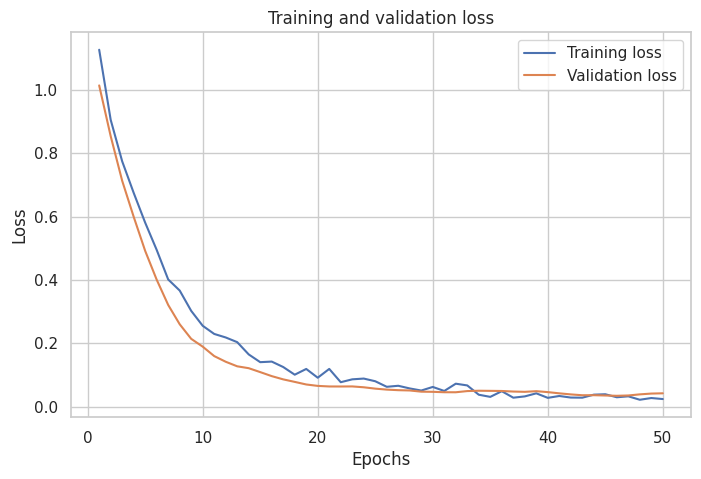

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 정확도 그래프

- 학습 정확도와 검증 정확도를 그래프로 나타낸다.
- 학습 정확도는 높은데 검증 정확도가 낮으면 일반화가 잘 되지 않은 것일 수 있다.

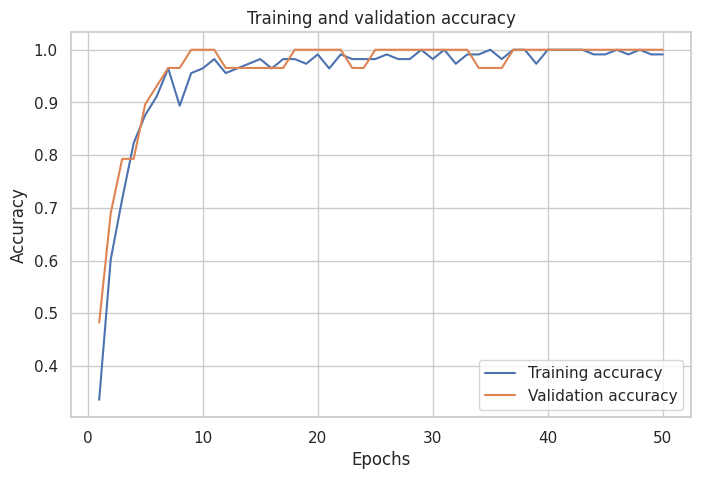

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 5. 전체 흐름 요약

이 코드는 다음 순서로 진행된다.

1. 입력 데이터 `X`를 NumPy 배열로 변환한다.
2. 정답 데이터 `y`를 원-핫 인코딩하여 `Y`를 만든다.
3. 데이터를 학습용과 테스트용으로 나눈다.
4. 학습 데이터 기준으로 표준화한다.
5. 신경망 모델을 생성한다.
6. 모델을 학습시킨다.
7. 테스트 데이터에 대해 예측한다.
8. 분류 성능을 평가한다.
9. 손실과 정확도 그래프로 학습 과정을 확인한다.